# Marine 48h Forecast — v6: DET-Inspired Univariate Transformer for the Hard 6

A sixth attempt at the 6 historically hard parameters (visibility ×4, precipitation ×2), inspired by
[Deep Extreme Transformer (DET)](https://ojs.aaai.org/index.php/AAAI/article/view/41189) (AAAI 2026),
built specifically for "extreme zero inflation... and pronounced nonstationarity" in rainfall.

**This is an adapted reconstruction, not a verified reproduction** — only DET's abstract-level
description was available, not its full equations or code. Two things are adapted deliberately
rather than copied verbatim, for reasons specific to this dataset:

1. **Univariate, not joint/multivariate.** Visibility-forecasting literature reports multivariate
   variants *underperforming* univariate ones, and this project's own v4 (TimeXer-lite, a Transformer
   applied jointly across the 4 visibility channels) was the worst visibility result found — it missed
   the test window's only fog dip almost entirely. Each of the 6 hard parameters gets its own
   independent model here, no cross-channel mixing at all.
2. **Different output head per variable, matched to its actual shape.** DET's headline idea — a
   **Tweedie distribution head** — assumes zero-inflated data (mostly zero, rare positive bursts):
   exactly precipitation's shape (82-96.5% exact zeros), so it's used as-is there. Visibility is the
   *opposite* shape — **ceiling-saturated** (sits near the sensor maximum almost always, with rare
   *drops*, not rare spikes from zero) — so a Tweedie head would be the wrong distributional
   assumption. Visibility instead gets a direct-regression head.

**What carries over from DET in spirit:** a patch-based Transformer backbone (similar to PatchTST),
plus a **rarity-weighted pooling mechanism** — instead of plain attention-pooling the patch
representations into one vector, each patch's pooling weight is boosted in proportion to how much
historical rare-event behavior (rain occurrence / low-visibility) it contains in its own lookback
data. This is DET's "emphasize rare but critical events" idea, implemented at the representation
level rather than via loss reweighting (the mechanism v3 tried and which backfired).

iTransformer for the 18 good parameters is **unchanged** and not touched by this notebook.
Standalone — does not modify any other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data, encode calendar features

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS

LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps
PATCH_LEN = 24
N_PATCHES = LOOKBACK // PATCH_LEN

idx = df_10min.index
calendar_df = pd.DataFrame({
    "hour_sin": np.sin(2 * np.pi * idx.hour / 24), "hour_cos": np.cos(2 * np.pi * idx.hour / 24),
    "dom_sin": np.sin(2 * np.pi * idx.day / 30), "dom_cos": np.cos(2 * np.pi * idx.day / 30),
}, index=idx)
calendar_cols = list(calendar_df.columns)

train_calendar = calendar_df.iloc[:-HORIZON]
test_calendar = calendar_df.iloc[-HORIZON:]
train_df = df_10min.iloc[:-HORIZON]
test_df = df_10min.iloc[-HORIZON:]
print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)  |  Test: {test_df.shape[0]} rows")

Train: 4032 rows (28.0 days)  |  Test: 288 rows


## 2. Patch-based univariate Transformer with rarity-weighted pooling

In [3]:
class RarityWeightedPatchTransformer(nn.Module):
    # Univariate: one channel in, one channel out. Patches the lookback, runs self-attention across
    # patches, then pools with attention weights boosted by each patch's own rare-event content
    # (DET's "emphasize rare but critical events", applied to pooling rather than loss/raw-attention).
    def __init__(self, lookback, n_calendar, horizon, patch_len=24, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1, rarity_boost=2.0, positive_head=False):
        super().__init__()
        self.n_patches = lookback // patch_len
        self.patch_len = patch_len
        self.horizon = horizon
        self.rarity_boost = rarity_boost
        self.positive_head = positive_head

        self.patch_embed = nn.Linear(patch_len * (1 + n_calendar), d_model)
        self.pos_embed = nn.Parameter(torch.randn(self.n_patches, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.pool_query = nn.Parameter(torch.randn(d_model) * 0.02)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x_target, x_calendar, rarity_score):
        # x_target: (B, lookback, 1), x_calendar: (B, lookback, n_calendar), rarity_score: (B, n_patches)
        B = x_target.shape[0]
        x = torch.cat([x_target, x_calendar], dim=-1)                     # (B, lookback, 1+n_calendar)
        patches = x.reshape(B, self.n_patches, self.patch_len * x.shape[-1])
        tok = self.patch_embed(patches) + self.pos_embed.unsqueeze(0)      # (B, n_patches, d_model)
        enc = self.encoder(tok)                                           # (B, n_patches, d_model)

        attn_logits = enc @ self.pool_query                                # (B, n_patches)
        base_weight = torch.softmax(attn_logits, dim=-1)
        boosted = base_weight * (1.0 + self.rarity_boost * rarity_score)
        pool_weight = boosted / boosted.sum(dim=-1, keepdim=True).clamp_min(1e-8)

        pooled = (enc * pool_weight.unsqueeze(-1)).sum(dim=1)              # (B, d_model)
        out = self.head(pooled)                                           # (B, horizon)
        if self.positive_head:
            out = torch.nn.functional.softplus(out)
        return out


def make_rarity_score(arr_2d, n_patches, patch_len, rarity_fn):
    # arr_2d: (n_windows, lookback) raw lookback windows -> (n_windows, n_patches) rarity score per patch
    reshaped = arr_2d.reshape(arr_2d.shape[0], n_patches, patch_len)
    return rarity_fn(reshaped).mean(axis=-1)


def tweedie_deviance_loss(mu, y, p=1.5, eps=1e-6):
    mu = mu.clamp_min(eps)
    a = y * torch.pow(mu, 1 - p) / (1 - p)
    b = torch.pow(mu, 2 - p) / (2 - p)
    return (-a + b).mean()


def train_model(model, train_batches, val_batches, epochs=150, lr=1e-3, patience=20, name="",
                 loss_fn=None):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    best_val, best_state, wait = float("inf"), None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        for xt, xc, rs, y in train_batches(shuffle=True):
            opt.zero_grad()
            pred = model(xt, xc, rs)
            loss = loss_fn(pred, y)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_losses = [loss_fn(model(xt, xc, rs), y).item() for xt, xc, rs, y in val_batches(shuffle=False)]
        val_loss = float(np.mean(val_losses))
        sched.step(val_loss)
        if val_loss < best_val - 1e-6:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:28s} best_val_loss={best_val:.5f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

## 3. Windowing helper (shared by both precipitation and visibility)

In [4]:
def build_windows(series_raw, calendar_arr, lookback, horizon):
    n = len(series_raw)
    X_t, X_c, Y = [], [], []
    for origin in range(lookback, n - horizon):
        X_t.append(series_raw[origin - lookback:origin])
        X_c.append(calendar_arr[origin - lookback:origin])
        Y.append(series_raw[origin:origin + horizon])
    return np.array(X_t, dtype=np.float32), np.array(X_c, dtype=np.float32), np.array(Y, dtype=np.float32)


def make_batches(Xt, Xc, RS, Y, batch_size=64):
    Xt_t, Xc_t, RS_t, Y_t = (torch.from_numpy(Xt), torch.from_numpy(Xc),
                              torch.from_numpy(RS), torch.from_numpy(Y))
    n = len(Xt_t)
    def gen(shuffle=True):
        idx = torch.randperm(n) if shuffle else torch.arange(n)
        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            yield (Xt_t[b].unsqueeze(-1).to(device), Xc_t[b].to(device),
                   RS_t[b].to(device), Y_t[b].to(device))
    return gen

## 4. Train the precipitation models (Tweedie head, rarity = historical rain occurrence)

In [5]:
precip_models = {}
precip_pred = {}
for c in PRECIP_PARAMS:
    series_train = train_df[c].values.astype(np.float32)
    cal_train = train_calendar.values.astype(np.float32)
    Xt, Xc, Y = build_windows(series_train, cal_train, LOOKBACK, HORIZON)
    rarity_fn = lambda patches: (patches > 0).astype(np.float32)
    RS = make_rarity_score(Xt, N_PATCHES, PATCH_LEN, rarity_fn)

    n = len(Xt); n_val = max(1, int(0.1 * n))
    perm = np.random.permutation(n)
    val_idx, tr_idx = perm[:n_val], perm[n_val:]
    train_gen = make_batches(Xt[tr_idx], Xc[tr_idx], RS[tr_idx], Y[tr_idx])
    val_gen = make_batches(Xt[val_idx], Xc[val_idx], RS[val_idx], Y[val_idx])

    model = RarityWeightedPatchTransformer(LOOKBACK, len(calendar_cols), HORIZON, patch_len=PATCH_LEN,
                                            d_model=64, n_heads=4, n_layers=2, rarity_boost=2.0,
                                            positive_head=True)
    model = train_model(model, train_gen, val_gen, epochs=150, patience=20, name=f"DET-precip:{c}",
                         loss_fn=lambda mu, y: tweedie_deviance_loss(mu, y, p=1.5))
    precip_models[c] = model

    last_t = torch.from_numpy(series_train[-LOOKBACK:]).unsqueeze(0).unsqueeze(-1)
    last_c = torch.from_numpy(cal_train[-LOOKBACK:]).unsqueeze(0)
    last_rs = torch.from_numpy(make_rarity_score(series_train[-LOOKBACK:].reshape(1, -1), N_PATCHES,
                                                  PATCH_LEN, rarity_fn)).float()
    with torch.no_grad():
        pred = model(last_t.to(device), last_c.to(device), last_rs.to(device))[0].cpu().numpy()
    precip_pred[c] = np.clip(pred, 0, None)
print("Precipitation models trained.")

DET-precip:precipitationIntensity best_val_loss=0.25768  epochs_run=150  time= 69.7s


DET-precip:precipitationDifference best_val_loss=1.19603  epochs_run= 66  time= 30.7s
Precipitation models trained.


## 5. Train the visibility models (regression head, rarity = historical low-visibility tail)

In [6]:
visibility_models = {}
visibility_pred = {}
for c in VISIBILITY_PARAMS:
    series_train = train_df[c].values.astype(np.float32)
    cal_train = train_calendar.values.astype(np.float32)
    Xt, Xc, Y = build_windows(series_train, cal_train, LOOKBACK, HORIZON)
    thresh = np.quantile(series_train, 0.10)
    rarity_fn = lambda patches, t=thresh: (patches < t).astype(np.float32)
    RS = make_rarity_score(Xt, N_PATCHES, PATCH_LEN, rarity_fn)

    mean_c, std_c = series_train.mean(), series_train.std()
    Xt_s = (Xt - mean_c) / std_c
    Y_s = (Y - mean_c) / std_c

    n = len(Xt_s); n_val = max(1, int(0.1 * n))
    perm = np.random.permutation(n)
    val_idx, tr_idx = perm[:n_val], perm[n_val:]
    train_gen = make_batches(Xt_s[tr_idx], Xc[tr_idx], RS[tr_idx], Y_s[tr_idx])
    val_gen = make_batches(Xt_s[val_idx], Xc[val_idx], RS[val_idx], Y_s[val_idx])

    model = RarityWeightedPatchTransformer(LOOKBACK, len(calendar_cols), HORIZON, patch_len=PATCH_LEN,
                                            d_model=64, n_heads=4, n_layers=2, rarity_boost=2.0,
                                            positive_head=False)
    huber = nn.SmoothL1Loss()
    model = train_model(model, train_gen, val_gen, epochs=150, patience=20, name=f"DET-visibility:{c}",
                         loss_fn=lambda pred, y: huber(pred, y))
    visibility_models[c] = model

    last_t = torch.from_numpy(((series_train[-LOOKBACK:]) - mean_c) / std_c).unsqueeze(0).unsqueeze(-1)
    last_c = torch.from_numpy(cal_train[-LOOKBACK:]).unsqueeze(0)
    last_rs = torch.from_numpy(make_rarity_score(series_train[-LOOKBACK:].reshape(1, -1), N_PATCHES,
                                                  PATCH_LEN, rarity_fn)).float()
    with torch.no_grad():
        pred_s = model(last_t.to(device), last_c.to(device), last_rs.to(device))[0].cpu().numpy()
    visibility_pred[c] = pred_s * std_c + mean_c
print("Visibility models trained.")

DET-visibility:twentyFourHourAvgVisibility best_val_loss=0.00850  epochs_run=150  time= 82.2s


DET-visibility:tenMinuteAvgVisibility best_val_loss=0.04888  epochs_run=150  time=111.1s


DET-visibility:oneMinuteAvgVisibility best_val_loss=0.06371  epochs_run=150  time=117.5s


DET-visibility:oneHourAvgVisibility best_val_loss=0.04511  epochs_run=150  time=127.8s
Visibility models trained.


## 6. Score against persistence and all five prior hard-6 approaches

In [7]:
PURE_ITRANSFORMER_SKILL = {
    "twentyFourHourAvgVisibility": -100.0, "precipitationDifference": -101.9,
    "tenMinuteAvgVisibility": -154.9, "oneMinuteAvgVisibility": -190.5,
    "oneHourAvgVisibility": -291.6, "precipitationIntensity": -409.9,
}
DEEPAR_HYBRID_SKILL = {
    "tenMinuteAvgVisibility": 14.0, "twentyFourHourAvgVisibility": 3.5,
    "precipitationDifference": -0.1, "precipitationIntensity": -0.2,
    "oneHourAvgVisibility": -1.4, "oneMinuteAvgVisibility": -2.5,
}
XGB_V2_SKILL = {
    "tenMinuteAvgVisibility": 11.8, "precipitationIntensity": -0.1,
    "precipitationDifference": -0.6, "oneMinuteAvgVisibility": -4.2,
    "twentyFourHourAvgVisibility": -7.0, "oneHourAvgVisibility": -7.5,
}
XGB_V3_SKILL = {
    "tenMinuteAvgVisibility": 5.0, "twentyFourHourAvgVisibility": -0.1,
    "oneMinuteAvgVisibility": -15.4, "oneHourAvgVisibility": -26.3,
    "precipitationDifference": -34.2, "precipitationIntensity": -74.9,
}
TIMEXER_V4_SKILL = {
    "tenMinuteAvgVisibility": -10.5, "twentyFourHourAvgVisibility": -16.6,
    "precipitationIntensity": -25.0, "precipitationDifference": -29.6,
    "oneMinuteAvgVisibility": -33.3, "oneHourAvgVisibility": -54.3,
}
RESIDUAL_V5_SKILL = {
    "twentyFourHourAvgVisibility": -20.9, "tenMinuteAvgVisibility": -56.2,
    "oneMinuteAvgVisibility": -60.7, "oneHourAvgVisibility": -79.8,
    "precipitationIntensity": -88.0, "precipitationDifference": -103.0,
}

all_pred = {**precip_pred, **visibility_pred}
truth = df_10min.iloc[-HORIZON:]
last_obs = df_10min.iloc[-HORIZON - 1]

metrics = []
for c in HARD_PARAMS:
    yt = truth[c].values
    yp_persist = np.repeat(last_obs[c], HORIZON)
    mae_p = mean_absolute_error(yt, yp_persist)
    mae = mean_absolute_error(yt, all_pred[c])
    rmse = np.sqrt(mean_squared_error(yt, all_pred[c]))
    skill = (1 - mae / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": c, "Persistence_MAE": round(mae_p, 4),
        "det_v6_MAE": round(mae, 4), "det_v6_RMSE": round(rmse, 4), "det_v6_skill_%": round(skill, 1),
        "pure_iTransformer_skill_%": PURE_ITRANSFORMER_SKILL[c],
        "deepar_hybrid_skill_%": DEEPAR_HYBRID_SKILL[c], "xgb_v2_skill_%": XGB_V2_SKILL[c],
        "xgb_v3_skill_%": XGB_V3_SKILL[c], "timexer_v4_skill_%": TIMEXER_V4_SKILL[c],
        "residual_v5_skill_%": RESIDUAL_V5_SKILL[c],
    })

metrics_df = pd.DataFrame(metrics).sort_values("det_v6_skill_%", ascending=False).reset_index(drop=True)
metrics_df.to_csv("metrics_det_v6.csv", index=False)
print(metrics_df.to_string(index=False))

means = {col: metrics_df[col].mean() for col in
         ["pure_iTransformer_skill_%", "deepar_hybrid_skill_%", "xgb_v2_skill_%", "xgb_v3_skill_%",
          "timexer_v4_skill_%", "residual_v5_skill_%", "det_v6_skill_%"]}
for k, v in means.items():
    print(f"{k:28s} mean = {v:+6.1f}%")

best_prior = max(means["deepar_hybrid_skill_%"], means["xgb_v2_skill_%"])
n_beats_best_prior = int((metrics_df["det_v6_skill_%"] >
                           metrics_df[["deepar_hybrid_skill_%", "xgb_v2_skill_%"]].max(axis=1)).sum())
print(f"\nv6 (DET-inspired) beats the best of (DeepAR-hybrid, XGBoost v2) on {n_beats_best_prior}/6 parameters")
if means["det_v6_skill_%"] > best_prior:
    print(f"VERDICT: v6 is the new best result for the hard 6 (mean {means['det_v6_skill_%']:+.1f}% "
          f"vs prior best {best_prior:+.1f}%).")
else:
    print(f"VERDICT: v6 ({means['det_v6_skill_%']:+.1f}%) does not beat the prior best "
          f"({best_prior:+.1f}%) -- DeepAR-hybrid/XGBoost v2 remain the best results found.")

                  parameter  Persistence_MAE  det_v6_MAE  det_v6_RMSE  det_v6_skill_%  pure_iTransformer_skill_%  deepar_hybrid_skill_%  xgb_v2_skill_%  xgb_v3_skill_%  timexer_v4_skill_%  residual_v5_skill_%
     tenMinuteAvgVisibility         544.7616    454.7903    1836.9895            16.5                     -154.9                   14.0            11.8             5.0               -10.5                -56.2
     oneMinuteAvgVisibility         485.5611    481.8464    1848.0397             0.8                     -190.5                   -2.5            -4.2           -15.4               -33.3                -60.7
       oneHourAvgVisibility         357.1536    366.7498    1574.2414            -2.7                     -291.6                   -1.4            -7.5           -26.3               -54.3                -79.8
    precipitationDifference           0.5839      0.6018       1.4470            -3.1                     -101.9                   -0.1            -0.6           -3

## 7. Plot all 6, v6 vs actual

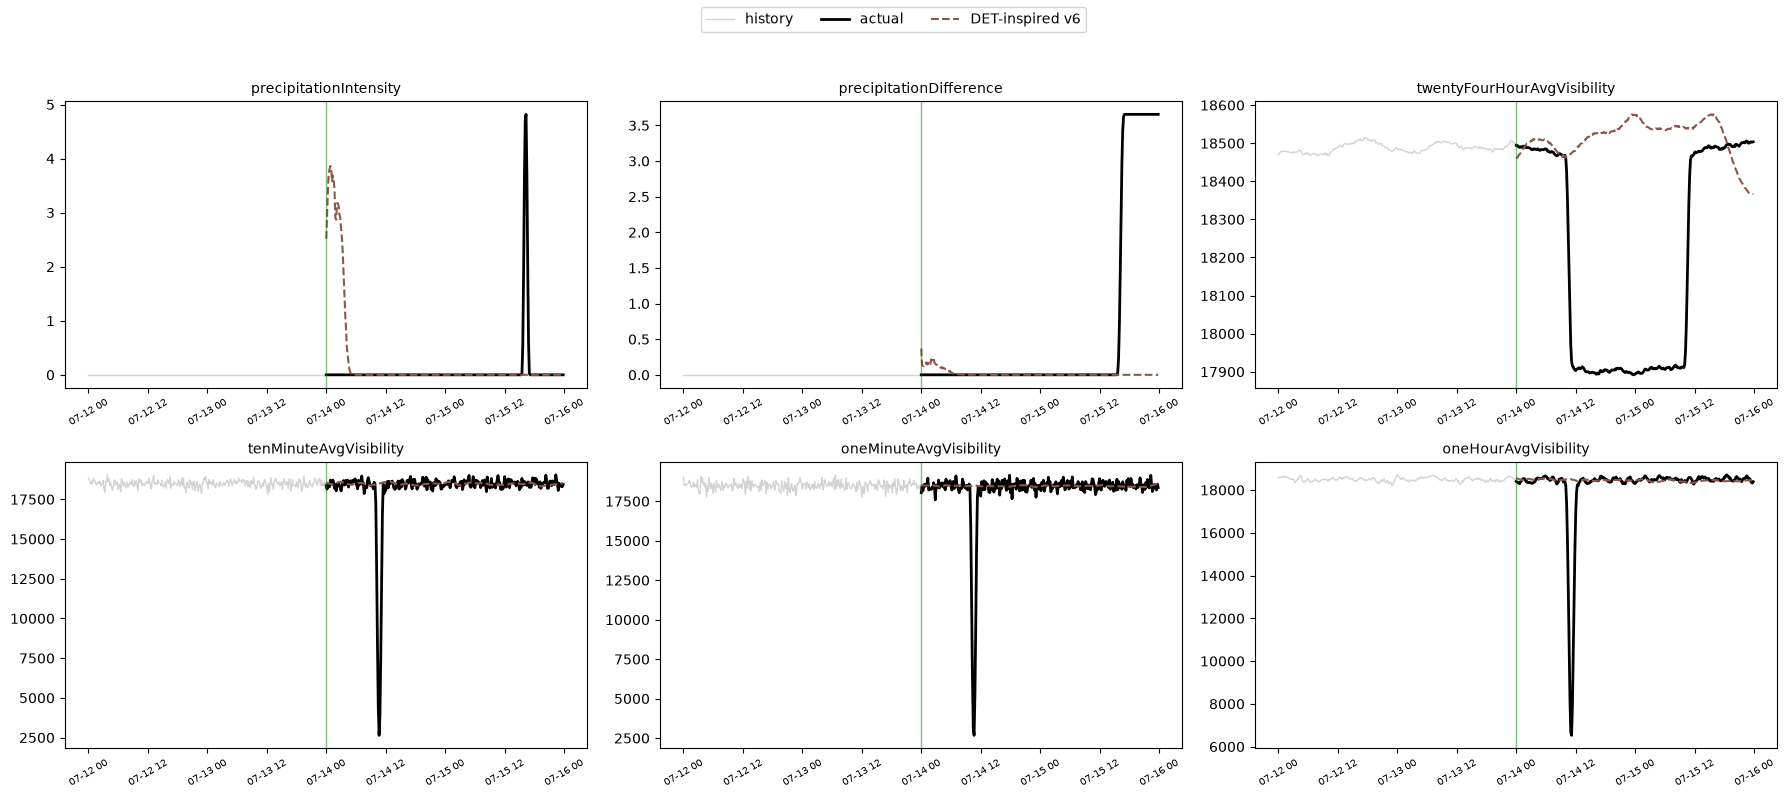

Saved det_v6_hard6_plot.png


In [8]:
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), HARD_PARAMS):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, all_pred[c], color="#8c564b", lw=1.5, ls="--", label="DET-inspired v6")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("det_v6_hard6_plot.png", dpi=110)
plt.show()
print("Saved det_v6_hard6_plot.png")

## 8. Save outputs for the dashboard

In [9]:
fva = pd.DataFrame({"timestamp": truth.index})
for c in HARD_PARAMS:
    fva[f"{c}__actual"] = truth[c].values
    fva[f"{c}__det_v6"] = all_pred[c]
fva.to_csv("forecast_vs_actual_det_v6.csv", index=False)
print("Saved: metrics_det_v6.csv, forecast_vs_actual_det_v6.csv, det_v6_hard6_plot.png")

Saved: metrics_det_v6.csv, forecast_vs_actual_det_v6.csv, det_v6_hard6_plot.png


## 9. Conclusion

Section 6 is the actual verdict. This is the sixth attempt at the hard 6, and the first to (a) go
fully univariate per parameter, (b) match the output head's distributional assumption to each
variable's actual shape (Tweedie for zero-inflated precipitation, direct regression for
ceiling-saturated visibility), and (c) emphasize rare-event patches via representation-level pooling
rather than loss reweighting. If it doesn't beat the prior best (DeepAR-hybrid, +2.2% mean skill),
that continues to point at data volume — not architecture, not distributional fit, not loss
mechanism — as the actual ceiling for these 6 parameters at 28 days of training history. Reported
honestly either way.